<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h2 style="margin-bottom: 6px;">Day 9 — Notebook 4</h2>
<h3 style="margin-top: 0;">Cross-Validation, StackingClassifier, and Model Diversity</h3>

<p>
This notebook continues the Day 9 Ensemble Learning project after the Random Forest and Bagging work in Notebook 3.
Here we compare individual base learners using cross-validation and then build stacking models that combine those learners through a meta-model.
</p>


<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Notebook objective:</b><br>
  Compare <b>Random Forest</b>, <b>Logistic Regression</b>, <b>KNN</b>, and <b>Decision Tree</b> against a <b>StackingClassifier</b>. Then test whether the meta-model choice changes performance.
</div>


<p>
The notebook includes short theory reminders for the important topics, but keeps the main focus on clean practical implementation, outputs, and interpretation.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important points for understanding</h3>

<table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
  <thead>
    <tr>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Concept</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Simple meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><b>Cross-validation</b></td>
      <td style="padding: 6px;">Split the training data into folds, test each fold once, and average the scores.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Base learners</b></td>
      <td style="padding: 6px;">The first-level models that give predictions, such as Random Forest, Logistic Regression, KNN, and Decision Tree.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Meta-model</b></td>
      <td style="padding: 6px;">The final model that learns how to combine the base learners' predictions.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Model diversity</b></td>
      <td style="padding: 6px;">The base learners should make different kinds of mistakes, so stacking has useful information to combine.</td>
    </tr>
  </tbody>
</table>


<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important warning:</b><br>
  Stacking is not automatically better. It helps only when base models add different useful information and the meta-model does not overfit.
</div>


</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Theory reminder: Why cross-validation matters here</h3>

<p>
Cross-validation gives a more reliable model comparison than one single train/test split.
In <b>5-fold stratified cross-validation</b>, the training data is split into five folds. Each fold becomes the validation fold once, and the final score is the average across all folds.
</p>


<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  <b>CV answers:</b> How well does this model perform across several train/validation rotations, not just one lucky or unlucky split?
</div>


</div>

In [1]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Plotting library
import matplotlib.pyplot as plt

# File and model saving utilities
from pathlib import Path
import joblib

# Scikit-learn preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Scikit-learn model selection and evaluation tools
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Base models and stacking model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

# Global random seed for reproducible results
RANDOM_STATE = 42

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">1. Load data from Notebook 2</h3>

<p>
Notebook 2 saved the train/test split. Here we load those files and continue the workflow without repeating the full data preparation process.
</p>

</div>

In [2]:
# Define project folders used across Day 9 notebooks.
# These paths are relative, so the notebook remains portable.
data_dir = Path("data")
processed_dir = data_dir / "processed"
reports_dir = Path("reports")
models_dir = Path("models")
figures_dir = Path("figures")

# Create output folders if they do not exist yet.
# This makes the notebook safe to run from a clean project folder.
reports_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

# Define the files created by Notebook 2.
X_train_path = processed_dir / "day9_X_train_raw.csv"
X_test_path = processed_dir / "day9_X_test_raw.csv"
y_train_path = processed_dir / "day9_y_train.csv"
y_test_path = processed_dir / "day9_y_test.csv"

# Check whether the required files exist before loading.
required_files = [X_train_path, X_test_path, y_train_path, y_test_path]
missing_files = [str(file_path) for file_path in required_files if not file_path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Notebook 4 needs the train/test files from Notebook 2. "
        f"Missing files: {missing_files}"
    )

# Load raw train/test features.
# These are unprocessed; preprocessing happens inside the model pipelines.
X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)

# Load target vectors and convert single-column DataFrames into Series.
y_train = pd.read_csv(y_train_path).squeeze("columns")
y_test = pd.read_csv(y_test_path).squeeze("columns")

print("Data loaded successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Data loaded successfully.
X_train shape: (8929, 16)
X_test shape:  (2233, 16)
y_train shape: (8929,)
y_test shape:  (2233,)


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">2. Rebuild the preprocessing pipeline</h3>

<p>
Each model receives the same preprocessing logic: numeric features are imputed and scaled, while categorical features are imputed and one-hot encoded.
</p>


<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point:</b><br>
  The preprocessing is placed inside each pipeline. During cross-validation, this prevents data leakage because preprocessing is fitted only on the training fold.
</div>


</div>

In [ ]:
# Separate numeric and categorical columns from the raw feature table.
# All columns in X_train are input features because the target was saved separately.

numeric_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print(f"Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"Categorical columns ({len(categorical_columns)}): {categorical_columns}")

# Numeric preprocessing:
# 1. Fill missing numeric values with the median.
# 2. Scale values so Logistic Regression and KNN are not dominated by large-scale features.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing:
# 1. Fill missing categorical values with the most frequent category.
# 2. Convert categories into one-hot encoded columns.
try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Compatibility fallback for older scikit-learn versions.
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", categorical_encoder),
])

# Combine numeric and categorical preprocessing into one transformer.
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_columns),
    ("categorical", categorical_transformer, categorical_columns),
])

Numeric columns (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">3. Define base learners and CV setup</h3>

<p>
The MVD requires four base learners: <b>Random Forest</b>, <b>Logistic Regression</b>, <b>KNN</b>, and <b>Decision Tree</b>.
They are intentionally different so we can test model diversity.
</p>

</div>

In [ ]:
# Helper function to create a full pipeline for any model.
# This keeps the code simple and avoids repeating Pipeline(...) manually.

def make_pipeline_for_model(model):
    """Create a full modelling pipeline with preprocessing + model."""
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

# Define base learners.
# Random Forest uses the strong configuration from Notebook 3: 100 trees and max_features=0.5.

base_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_features=0.5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15,
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
    ),
}

# StratifiedKFold keeps the target ratio similar in each fold.
# This is useful because we want each fold to represent both target classes fairly.

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Evaluation metrics used across all models.
# Accuracy is useful because the target is almost balanced.
# F1 and ROC-AUC give extra quality checks for the subscribed class.

scoring = {
    "Accuracy": "accuracy",
    "F1": "f1",
    "ROC_AUC": "roc_auc",
}

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important Point: Base Models and Cross-Validation Setup</h3>

<p>
This section prepares the models and evaluation strategy for stacking.
The helper function <code>make_pipeline_for_model()</code> creates a full pipeline with preprocessing and a selected model.
This keeps the code clean and avoids repeating the same pipeline structure many times.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  The base models act like different experts. Random Forest, Logistic Regression, KNN, and Decision Tree each learn the problem in a different way.
</div>

<p>
The cross-validation strategy uses <b>5-fold StratifiedKFold</b>.
This means the data is split into five folds while keeping the subscribed and not-subscribed ratio similar in each fold.
This gives a fairer model comparison.
</p>

<p>
We evaluate every model using <b>Accuracy</b>, <b>F1-score</b>, and <b>ROC-AUC</b>.
Accuracy gives the overall correctness, F1-score balances precision and recall for the subscribed class,
and ROC-AUC measures how well the model separates subscribers from non-subscribers.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">4. Cross-validate individual base learners</h3>

<p>
Before stacking, we first evaluate every base learner separately. This tells us whether stacking actually improves over the individual models.
</p>

</div>

In [13]:
# Evaluate each base learner with the same 5-fold CV strategy.
# The mean score shows average performance; the standard deviation shows stability across folds.
base_cv_rows = []
trained_base_pipelines = {}

for model_name, model in base_models.items():
    print(f"Evaluating: {model_name}")

    # Build preprocessing + model pipeline for the current model.
    model_pipeline = make_pipeline_for_model(model)

    # Run cross-validation.
    # The model is trained and validated five times on different folds.
    cv_scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=None,
        return_train_score=False,
    )

    # Store mean and standard deviation for every metric.
    base_cv_rows.append({
        "Model": model_name,
        "CV_Accuracy_Mean": cv_scores["test_Accuracy"].mean(),
        "CV_Accuracy_Std": cv_scores["test_Accuracy"].std(),
        "CV_F1_Mean": cv_scores["test_F1"].mean(),
        "CV_F1_Std": cv_scores["test_F1"].std(),
        "CV_ROC_AUC_Mean": cv_scores["test_ROC_AUC"].mean(),
        "CV_ROC_AUC_Std": cv_scores["test_ROC_AUC"].std(),
    })

    # Fit model on full training data after CV for possible later inspection.
    model_pipeline.fit(X_train, y_train)
    trained_base_pipelines[model_name] = model_pipeline

# Convert collected rows into a clean comparison table.
base_cv_results = (
    pd.DataFrame(base_cv_rows)
    .sort_values("CV_F1_Mean", ascending=False)
    .reset_index(drop=True)
)

# Round metrics for a clean display table.
base_cv_results_rounded = base_cv_results.copy()
metric_columns = [col for col in base_cv_results_rounded.columns if col != "Model"]
base_cv_results_rounded[metric_columns] = base_cv_results_rounded[metric_columns].round(4)

display(base_cv_results_rounded)

Evaluating: Random Forest
Evaluating: Logistic Regression
Evaluating: KNN
Evaluating: Decision Tree


,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Random Forest,0.8525,0.0048,0.8496,0.0053,0.9199,0.0048
1,Logistic Regression,0.8245,0.0076,0.8108,0.0101,0.9015,0.0043
2,KNN,0.8093,0.0104,0.7899,0.0117,0.8902,0.0060
3,Decision Tree,0.7939,0.0012,0.7819,0.0022,0.7932,0.0013


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Base Learner Cross-Validation Comparison</h3>

<p>
The cross-validation comparison shows that <b>Random Forest is the strongest base learner</b>
among the four models tested.
It achieved the highest mean Accuracy, F1-score, and ROC-AUC across the 5 folds.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best base learner:</b><br>
  Random Forest achieved <b>85.25% CV accuracy</b>, <b>84.96% CV F1-score</b>,
  and <b>91.99% CV ROC-AUC</b>.
</div>

<p>
Logistic Regression is the second-best model, with a CV F1-score of <b>81.08%</b>
and ROC-AUC of <b>90.15%</b>. This confirms that the dataset has strong predictive signals
that can be captured even by a simpler model.
</p>

<p>
KNN performs reasonably, but it is weaker than Random Forest and Logistic Regression.
The single Decision Tree is the weakest model, which matches the previous notebook:
one tree is more unstable and less generalizable than a forest of trees.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  Cross-validation tests each model across multiple folds.
  The low standard deviation for Random Forest shows that its performance is stable,
  not just good because of one lucky train/test split.
</div>

<p>
From a stacking point of view, this table is important because the base learners are not equally strong.
Random Forest is clearly the strongest expert, while Logistic Regression, KNN, and Decision Tree provide different modelling perspectives.
The next question is whether stacking can combine these different perspectives and improve beyond the best individual model.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Theory reminder: What StackingClassifier does</h3>

<p>
A <b>StackingClassifier</b> trains several base learners first. Their predictions become new inputs for a final <b>meta-model</b>.
</p>

<table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
  <thead>
    <tr>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Layer</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Models</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Role</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><b>Level 0</b></td>
      <td style="padding: 6px;">Random Forest, Logistic Regression, KNN, Decision Tree</td>
      <td style="padding: 6px;">Different experts produce predictions.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Level 1</b></td>
      <td style="padding: 6px;">Meta-model</td>
      <td style="padding: 6px;">Learns how to combine expert predictions.</td>
    </tr>
  </tbody>
</table>


<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  Random Forest combines many similar tree experts. Stacking combines different types of experts and learns how to trust them.
</div>


</div>

Base learners:
Random Forest + Logistic Regression + KNN + Decision Tree

Final/meta-model:
Logistic Regression

Raw customer data

→ base models make predictions

→ Logistic Regression meta-model combines those predictions

→ final prediction

In [ ]:
# Define base learners for StackingClassifier.
# StackingClassifier expects a list of (short_name, model_object) tuples.

stacking_base_learners = [
    ("rf", RandomForestClassifier(
        n_estimators=100,
        max_features=0.5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
    ("log_reg", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
    ("knn", KNeighborsClassifier(
        n_neighbors=15,
    )),
    ("tree", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
    )),
]

# Required meta-model 1: Logistic Regression.
# This is simple, stable, and easy to explain.

logistic_meta_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)

# Build the StackingClassifier with Logistic Regression as final estimator.
# cv=5 means the stacker internally creates fold-based predictions for meta-model training.

stacking_lr_model = StackingClassifier(
    estimators=stacking_base_learners,
    final_estimator=logistic_meta_model,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
)

# Wrap the stacker inside the preprocessing pipeline.
stacking_lr_pipeline = make_pipeline_for_model(stacking_lr_model)

##### Stacking Classifier

stacking_lr_model = StackingClassifier(

    estimators=stacking_base_learners,

    final_estimator=logistic_meta_model,

    cv=5,

    stack_method="predict_proba",
    
    n_jobs=-1,
)

| Parameter                             | Meaning                                                   |
| ------------------------------------- | --------------------------------------------------------- |
| `estimators=stacking_base_learners`   | The base models / experts                                 |
| `final_estimator=logistic_meta_model` | The final meta-model                                      |
| `cv=5`                                | Uses 5-fold logic to create fair meta-features            |
| `stack_method="predict_proba"`        | Uses probability predictions instead of only class labels |
| `n_jobs=-1`                           | Uses available CPU cores for faster training              |


stacking_lr_pipeline = make_pipeline_for_model(stacking_lr_model)

This wraps the stacker inside the same preprocessing pipeline:

Raw data

→ preprocessor

→ StackingClassifier

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important Point: StackingClassifier with Logistic Regression Meta-Model</h3>

<p>
This section builds the first stacking model. The base learners are
<b>Random Forest</b>, <b>Logistic Regression</b>, <b>KNN</b>, and <b>Decision Tree</b>.
These models act like different experts because each model learns the customer subscription problem in a different way.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  Stacking does not simply average the models. It trains a final <b>meta-model</b>
  that learns how to combine the base-model predictions.
</div>

<p>
The final estimator in this version is <b>Logistic Regression</b>.
This is a good first meta-model because it is simple, stable, and easier to explain.
The stacker uses <code>cv=5</code>, meaning it creates fold-based predictions internally
to train the meta-model more fairly.
</p>

<p>
The setting <code>stack_method="predict_proba"</code> tells the stacker to use probability predictions
from the base models. This gives the meta-model richer information than hard class labels alone.
</p>

<p>
Finally, the stacking model is wrapped inside the same preprocessing pipeline.
This keeps the workflow consistent:
raw customer data is first preprocessed, then the stacking model is trained.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">5. Evaluate StackingClassifier with Logistic Regression meta-model</h3>

<p>
This is the first required stacking model. The base learners are Random Forest, Logistic Regression, KNN, and Decision Tree. The meta-model is Logistic Regression.
</p>

</div>

In [7]:
print("Evaluating: StackingClassifier with Logistic Regression meta-model")

# Cross-validate the stacking pipeline using the same CV setup and metrics.
stacking_lr_cv_scores = cross_validate(
    stacking_lr_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring,
    n_jobs=None,
    return_train_score=False,
)

# Store the stacking result in the same format as the base model table.
stacking_lr_cv_result = pd.DataFrame([{
    "Model": "StackingClassifier (LR meta)",
    "CV_Accuracy_Mean": stacking_lr_cv_scores["test_Accuracy"].mean(),
    "CV_Accuracy_Std": stacking_lr_cv_scores["test_Accuracy"].std(),
    "CV_F1_Mean": stacking_lr_cv_scores["test_F1"].mean(),
    "CV_F1_Std": stacking_lr_cv_scores["test_F1"].std(),
    "CV_ROC_AUC_Mean": stacking_lr_cv_scores["test_ROC_AUC"].mean(),
    "CV_ROC_AUC_Std": stacking_lr_cv_scores["test_ROC_AUC"].std(),
}])

# Combine base learners and stacking model into one comparison table.
cv_model_comparison = (
    pd.concat([base_cv_results, stacking_lr_cv_result], ignore_index=True)
    .sort_values("CV_F1_Mean", ascending=False)
    .reset_index(drop=True)
)

# Round for display.
cv_model_comparison_rounded = cv_model_comparison.copy()
metric_columns = [col for col in cv_model_comparison_rounded.columns if col != "Model"]
cv_model_comparison_rounded[metric_columns] = cv_model_comparison_rounded[metric_columns].round(4)

display(cv_model_comparison_rounded)

Evaluating: StackingClassifier with Logistic Regression meta-model


,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,StackingClassifier (LR meta),0.8544,0.0049,0.8500,0.0057,0.9225,0.0044
1,Random Forest,0.8525,0.0048,0.8496,0.0053,0.9199,0.0048
2,Logistic Regression,0.8245,0.0076,0.8108,0.0101,0.9015,0.0043
3,KNN,0.8093,0.0104,0.7899,0.0117,0.8902,0.0060
4,Decision Tree,0.7939,0.0012,0.7819,0.0022,0.7932,0.0013


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: StackingClassifier vs Base Learners</h3>

<p>
The cross-validation comparison shows that the <b>StackingClassifier with Logistic Regression as meta-model</b>
is the best-performing model overall. It achieved the highest mean CV accuracy and ROC-AUC among all models tested.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main result:</b><br>
  StackingClassifier achieved <b>85.44% CV accuracy</b>, <b>85.00% CV F1-score</b>,
  and <b>92.25% CV ROC-AUC</b>.
</div>

<p>
Random Forest remains very close behind, with <b>85.25% CV accuracy</b>,
<b>84.96% CV F1-score</b>, and <b>91.99% CV ROC-AUC</b>.
This means stacking does improve performance, but the improvement over Random Forest is small.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  Stacking technically outperforms every individual base learner in this comparison.
  However, the gain over Random Forest is marginal, so we must judge whether the extra complexity is worth it.
</div>

<p>
From a business point of view, stacking gives the strongest result so far, but Random Forest is still a very competitive and simpler model.
The next step is to test whether changing the meta-model from Logistic Regression to Random Forest improves performance further.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">6. Visualize CV model comparison</h3>

<p>
This chart compares average cross-validation F1-score. F1-score is useful because it balances precision and recall for the subscribed class.
</p>

</div>

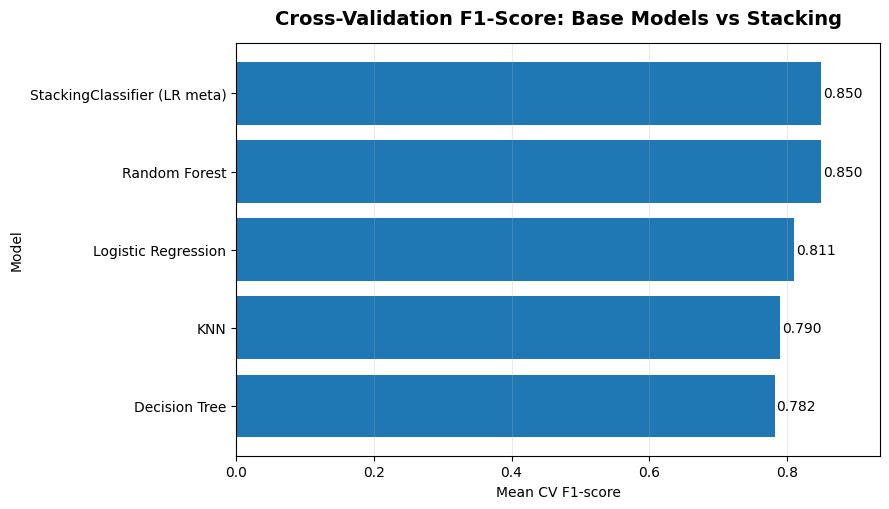

In [8]:
# Sort models by CV F1-score for a readable horizontal bar chart.
plot_data = cv_model_comparison.sort_values("CV_F1_Mean", ascending=True)

plt.figure(figsize=(9, 5.2))

# Draw one horizontal bar per model.
bars = plt.barh(
    plot_data["Model"],
    plot_data["CV_F1_Mean"],
)

plt.title("Cross-Validation F1-Score: Base Models vs Stacking", fontsize=14, weight="bold", pad=14)
plt.xlabel("Mean CV F1-score")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.25)

# Add value labels at the end of each bar.
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

# Add space on the right side for the labels.
plt.xlim(0, max(plot_data["CV_F1_Mean"]) * 1.10)
plt.tight_layout()

# Save chart for final documentation.
plt.savefig(figures_dir / "day9_notebook4_cv_f1_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

| Model                   | Main result                                            |
| ----------------------- | ------------------------------------------------------ |
| **StackingClassifier**  | Best overall CV accuracy and ROC-AUC                   |
| **Random Forest**       | Almost equal performance; still very strong            |
| **Logistic Regression** | Strong simple baseline, but clearly behind RF/stacking |
| **KNN**                 | Decent but weaker                                      |
| **Decision Tree**       | Weakest model                                          |


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Theory reminder: Model diversity</h3>

<p>
Stacking works best when base models are diverse. This means they should not all make exactly the same predictions or the same mistakes.
</p>


<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple rule:</b><br>
  If every base model thinks the same way, the meta-model has little new information to learn. If different models catch different patterns, stacking can become useful.
</div>


<p>
Here the model families are intentionally different: Random Forest captures stable nonlinear tree patterns, Logistic Regression captures global probability trends, KNN captures similar-customer behavior, and Decision Tree captures simple rule-based splits.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">7. Swap the meta-model: Logistic Regression to Random Forest</h3>

<p>
Swap the meta-model from Logistic Regression to Random Forest and check whether performance changes.
This tests whether a more flexible final combiner is helpful or unnecessarily complex.
</p>

</div>

In [ ]:
# Required meta-model 2: Random Forest.
# We keep max_depth controlled to reduce overfitting risk at the meta-model level.

random_forest_meta_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Build StackingClassifier with Random Forest as the meta-model.

stacking_rf_model = StackingClassifier(
    estimators=stacking_base_learners,
    final_estimator=random_forest_meta_model,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
)

# Wrap the stacker inside the same preprocessing pipeline.

stacking_rf_pipeline = make_pipeline_for_model(stacking_rf_model)

print("Evaluating: StackingClassifier with Random Forest meta-model")

# Cross-validate the RF-meta stacking pipeline.

stacking_rf_cv_scores = cross_validate(
    stacking_rf_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring,
    n_jobs=None,
    return_train_score=False,
)

# Compare both meta-model choices side by side.

meta_model_comparison = pd.DataFrame([
    {
        "Stacking_Model": "LR meta-model",
        "CV_Accuracy_Mean": stacking_lr_cv_scores["test_Accuracy"].mean(),
        "CV_Accuracy_Std": stacking_lr_cv_scores["test_Accuracy"].std(),
        "CV_F1_Mean": stacking_lr_cv_scores["test_F1"].mean(),
        "CV_F1_Std": stacking_lr_cv_scores["test_F1"].std(),
        "CV_ROC_AUC_Mean": stacking_lr_cv_scores["test_ROC_AUC"].mean(),
        "CV_ROC_AUC_Std": stacking_lr_cv_scores["test_ROC_AUC"].std(),
    },
    {
        "Stacking_Model": "Random Forest meta-model",
        "CV_Accuracy_Mean": stacking_rf_cv_scores["test_Accuracy"].mean(),
        "CV_Accuracy_Std": stacking_rf_cv_scores["test_Accuracy"].std(),
        "CV_F1_Mean": stacking_rf_cv_scores["test_F1"].mean(),
        "CV_F1_Std": stacking_rf_cv_scores["test_F1"].std(),
        "CV_ROC_AUC_Mean": stacking_rf_cv_scores["test_ROC_AUC"].mean(),
        "CV_ROC_AUC_Std": stacking_rf_cv_scores["test_ROC_AUC"].std(),
    },
]).sort_values("CV_F1_Mean", ascending=False)

# Round for clean display.
meta_model_comparison_rounded = meta_model_comparison.copy()
metric_columns = [col for col in meta_model_comparison_rounded.columns if col != "Stacking_Model"]
meta_model_comparison_rounded[metric_columns] = meta_model_comparison_rounded[metric_columns].round(4)

display(meta_model_comparison_rounded)

Evaluating: StackingClassifier with Random Forest meta-model


,Stacking_Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
1,Random Forest meta-model,0.8529,0.0066,0.8531,0.0073,0.9217,0.0040
0,LR meta-model,0.8544,0.0049,0.8500,0.0057,0.9225,0.0044


| Meta-model                         | Best at                        |
| ---------------------------------- | ------------------------------ |
| **Logistic Regression meta-model** | Higher CV Accuracy and ROC-AUC |
| **Random Forest meta-model**       | Higher CV F1-score             |


LR meta-model:

CV Accuracy = 85.44%

CV F1 = 85.00%

CV ROC-AUC = 92.25%

Random Forest meta-model:

CV Accuracy = 85.29%

CV F1 = 85.31%

CV ROC-AUC = 92.17%

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Logistic Regression vs Random Forest Meta-Model</h3>

<p>
This comparison tests whether changing the stacking meta-model improves performance.
The two meta-models behave slightly differently.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best F1-score:</b><br>
  The <b>Random Forest meta-model</b> achieved the higher CV F1-score:
  <b>85.31%</b> compared with <b>85.00%</b> for the Logistic Regression meta-model.
</div>

<p>
However, the <b>Logistic Regression meta-model</b> achieved slightly better CV accuracy
(<b>85.44%</b> vs. <b>85.29%</b>) and slightly better ROC-AUC
(<b>92.25%</b> vs. <b>92.17%</b>).
It also has a lower F1 standard deviation, which means its performance is slightly more stable across folds.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  A more complex meta-model does not automatically make stacking better.
  The Random Forest meta-model improves F1-score, but it also adds more complexity and slightly higher fold-to-fold variation.
</div>

<p>
From a business point of view, the choice depends on the goal.
If the campaign team wants the best balance between identifying subscribers and avoiding wrong targeting,
the Random Forest meta-model is useful.
If the team wants a simpler, more stable, and easier-to-explain stacking model,
the Logistic Regression meta-model is the stronger practical choice.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">8. Fit stacking models and evaluate on the test set</h3>

<p>
Cross-validation is the main fair comparison, but the test set gives a practical final check for business interpretation.
</p>

</div>

1. StackingClassifier with Logistic Regression meta-model

2. StackingClassifier with Random Forest meta-model

Logistic Regression:

lr_stack_pred = stacking_lr_pipeline.predict(X_test)

lr_stack_proba = stacking_lr_pipeline.predict_proba(X_test)[:, 1]

lr_stack_proba:
0 = Not subscribed
1 = Subscribed

The [:, 1] part means:

take the probability of class 1 = Subscribed

Random Forest:

rf_stack_pred = stacking_rf_pipeline.predict(X_test)

rf_stack_proba = stacking_rf_pipeline.predict_proba(X_test)[:, 1]

In [10]:
# Train both stacking pipelines on the full training set.
# This prepares them for final test-set evaluation and saving.
stacking_lr_pipeline.fit(X_train, y_train)
stacking_rf_pipeline.fit(X_train, y_train)

# Predict test labels and probabilities for LR-meta stacking.
lr_stack_pred = stacking_lr_pipeline.predict(X_test)
lr_stack_proba = stacking_lr_pipeline.predict_proba(X_test)[:, 1]

# Predict test labels and probabilities for RF-meta stacking.
rf_stack_pred = stacking_rf_pipeline.predict(X_test)
rf_stack_proba = stacking_rf_pipeline.predict_proba(X_test)[:, 1]

# Build test-set comparison table.
test_stacking_results = pd.DataFrame([
    {
        "Model": "StackingClassifier (LR meta)",
        "Test_Accuracy": accuracy_score(y_test, lr_stack_pred),
        "Test_Precision": precision_score(y_test, lr_stack_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, lr_stack_pred, zero_division=0),
        "Test_F1": f1_score(y_test, lr_stack_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, lr_stack_proba),
    },
    {
        "Model": "StackingClassifier (RF meta)",
        "Test_Accuracy": accuracy_score(y_test, rf_stack_pred),
        "Test_Precision": precision_score(y_test, rf_stack_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, rf_stack_pred, zero_division=0),
        "Test_F1": f1_score(y_test, rf_stack_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, rf_stack_proba),
    },
]).sort_values("Test_F1", ascending=False)

# Round for display.
test_stacking_results_rounded = test_stacking_results.copy()
metric_columns = [col for col in test_stacking_results_rounded.columns if col != "Model"]
test_stacking_results_rounded[metric_columns] = test_stacking_results_rounded[metric_columns].round(4)

display(test_stacking_results_rounded)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
1,StackingClassifier (RF meta),0.8598,0.8176,0.9064,0.8597,0.9247
0,StackingClassifier (LR meta),0.8589,0.8338,0.8771,0.8549,0.9265


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Held-Out Test Comparison of Stacking Models</h3>

<p>
The held-out test evaluation compares two stacking models on unseen customer data:
one with a <b>Logistic Regression meta-model</b> and one with a <b>Random Forest meta-model</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best F1-score:</b><br>
  The <b>Random Forest meta-model</b> achieved the higher test F1-score:
  <b>85.97%</b> compared with <b>85.49%</b> for the Logistic Regression meta-model.
</div>

<p>
The Random Forest meta-model also achieved slightly higher test accuracy
(<b>85.98%</b> vs. <b>85.89%</b>) and much higher recall
(<b>90.64%</b> vs. <b>87.71%</b>).
This means it catches more actual subscribers, which is valuable for a marketing campaign use case.
</p>

<p>
The Logistic Regression meta-model achieved better precision
(<b>83.38%</b> vs. <b>81.76%</b>) and slightly better ROC-AUC
(<b>92.65%</b> vs. <b>92.47%</b>).
This means it is slightly better at ranking customers and produces fewer false subscriber predictions.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  The best model depends on the business goal.
  If the goal is to catch more potential subscribers, the Random Forest meta-model is better.
  If the goal is cleaner probability ranking and fewer false positives, the Logistic Regression meta-model is still useful.
</div>

<p>
For this project, the <b>Random Forest meta-model stacking approach</b> is the stronger test-set model by F1-score.
However, the difference is not huge, so the final recommendation should consider both performance and explainability.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important Point: Test Evaluation</h3>

<p>
A <b>test set</b> is the part of the dataset that was kept separate from model training.
The model learns from the training data, and the test set is used later to check how well the model performs on unseen customers.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key idea:</b><br>
  Cross-validation checks model performance across training folds.
  The held-out test set gives a final check on data that was not used during training.
</div>

<p>
In this section, we train both stacking pipelines on the full training set:
one stacker uses <b>Logistic Regression</b> as the meta-model, and the other uses
<b>Random Forest</b> as the meta-model.
</p>

<p>
After training, both models predict the test set. We calculate
<b>accuracy</b>, <b>precision</b>, <b>recall</b>, <b>F1-score</b>, and <b>ROC-AUC</b>.
This allows us to compare which stacking approach performs better on unseen customer data.
</p>

<p>
The final comparison table is sorted by <b>F1-score</b>, because F1-score gives a useful balance between
catching actual subscribers and avoiding incorrect subscriber predictions.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">9. Inspect confusion matrix for the best stacking model</h3>

<p>
The best stacking model is selected by test F1-score. The confusion matrix helps us understand false positives and false negatives in business terms.
</p>

</div>

Best stacking model by test F1-score: StackingClassifier (RF meta)

Classification report:
                precision    recall  f1-score   support

Not subscribed       0.91      0.82      0.86      1175
    Subscribed       0.82      0.91      0.86      1058

      accuracy                           0.86      2233
     macro avg       0.86      0.86      0.86      2233
  weighted avg       0.86      0.86      0.86      2233



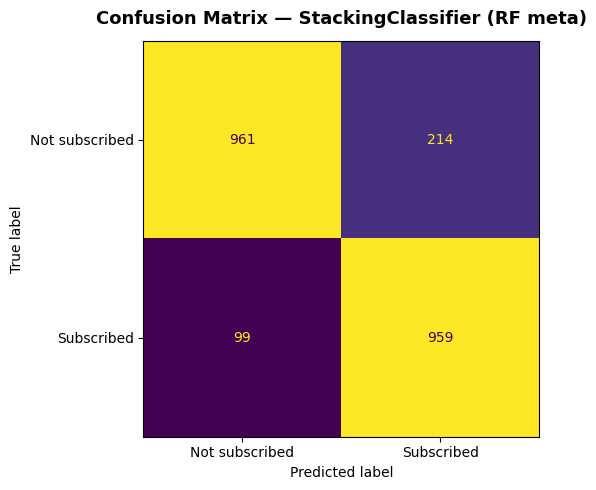

In [11]:
# Select the best stacking model based on test F1-score.
best_stacking_name = test_stacking_results.iloc[0]["Model"]

# Choose the correct predictions based on the selected best model.
if best_stacking_name == "StackingClassifier (LR meta)":
    best_stacking_pred = lr_stack_pred
else:
    best_stacking_pred = rf_stack_pred

print(f"Best stacking model by test F1-score: {best_stacking_name}")
print("\nClassification report:")
print(
    classification_report(
        y_test,
        best_stacking_pred,
        target_names=["Not subscribed", "Subscribed"],
        zero_division=0,
    )
)

# Create confusion matrix for the best stacking model.
cm = confusion_matrix(y_test, best_stacking_pred)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not subscribed", "Subscribed"],
)

fig, ax = plt.subplots(figsize=(6, 5))
cm_display.plot(ax=ax, values_format=",d", colorbar=False)
plt.title(f"Confusion Matrix — {best_stacking_name}", fontsize=13, weight="bold", pad=12)
plt.tight_layout()

# Save chart for final documentation.
plt.savefig(figures_dir / "day9_notebook4_best_stacking_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">10. Save Notebook 4 outputs</h3>

<p>
The saved outputs will be reused in later notebooks and final documentation.
</p>

</div>

In [12]:
# Save cross-validation comparison tables.
base_cv_results_rounded.to_csv(
    reports_dir / "day9_notebook4_base_model_cv_results.csv",
    index=False,
)

cv_model_comparison_rounded.to_csv(
    reports_dir / "day9_notebook4_base_vs_stacking_cv_results.csv",
    index=False,
)

meta_model_comparison_rounded.to_csv(
    reports_dir / "day9_notebook4_meta_model_comparison.csv",
    index=False,
)

test_stacking_results_rounded.to_csv(
    reports_dir / "day9_notebook4_test_stacking_results.csv",
    index=False,
)

# Save trained stacking models.
joblib.dump(
    stacking_lr_pipeline,
    models_dir / "day9_stacking_lr_meta_pipeline.joblib",
)

joblib.dump(
    stacking_rf_pipeline,
    models_dir / "day9_stacking_rf_meta_pipeline.joblib",
)

# Save a short summary for later notebooks.
notebook4_summary = pd.DataFrame([{
    "Best_CV_Model": cv_model_comparison.iloc[0]["Model"],
    "Best_CV_F1": cv_model_comparison.iloc[0]["CV_F1_Mean"],
    "Best_Stacking_Test_Model": best_stacking_name,
    "Best_Stacking_Test_F1": test_stacking_results.iloc[0]["Test_F1"],
    "Best_Stacking_Test_ROC_AUC": test_stacking_results.iloc[0]["Test_ROC_AUC"],
}])

notebook4_summary.to_csv(
    reports_dir / "day9_notebook4_summary.csv",
    index=False,
)

print("Notebook 4 outputs saved successfully.")
print(f"Reports saved in: {reports_dir}")
print(f"Models saved in: {models_dir}")
print(f"Figures saved in: {figures_dir}")

display(notebook4_summary.round(4))

Notebook 4 outputs saved successfully.
Reports saved in: reports
Models saved in: models
Figures saved in: figures


,Best_CV_Model,Best_CV_F1,Best_Stacking_Test_Model,Best_Stacking_Test_F1,Best_Stacking_Test_ROC_AUC
0,StackingClassifier (LR meta),0.85,StackingClassifier (RF meta),0.8597,0.9247


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Final Conclusion: Notebook 4</h3>

<p>
Notebook 4 compared individual base learners against stacking models using cross-validation and held-out test evaluation.
The best model during cross-validation was the <b>StackingClassifier with Logistic Regression meta-model</b>,
with a CV F1-score of <b>0.8500</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best held-out test model:</b><br>
  The <b>StackingClassifier with Random Forest meta-model</b> achieved the strongest held-out test result,
  with a <b>test F1-score of 0.8597</b> and <b>test ROC-AUC of 0.9247</b>.
</div>

<p>
This result shows that stacking can improve slightly over the individual base learners, especially when different model types
are combined. The base learners provide different views of the same customer prediction problem, and the meta-model learns
how to combine their predictions.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  The best cross-validation model and the best held-out test model are not always the same.
  Cross-validation gives a stable training-set estimate, while the held-out test set gives the final unseen-data check.
</div>

<p>
From a business point of view, the Random Forest meta-model is useful because it achieved the best F1-score on unseen data.
This means it gives the best balance between catching actual subscribers and avoiding incorrect subscriber predictions
among the stacking models tested in this notebook.
</p>

<p>
The next notebook will go deeper by manually building <b>Out-of-Fold stacking</b> and <b>Blending</b>.
This will help us understand how stacking works internally and how it compares with a simpler holdout-based blending approach.
</p>

</div>